In [1]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    

from RENDES_fizinfo import *

In [23]:
auto_raw = GPS_to_num_kinem('../GPS/szerviz-egyetem.txt', orig='first')
auto = num_kinem_smooth_r(auto_raw, 0.1, lam=3.715, err_report=True)

Adatsor pontosság: RMS=3.808; MAX=3.940
Eltérés          : RMS=0.642; MAX=3.940


Küszöb: 13.89 m/s
Küszöb feletti összidő: 63.5 s
Nagysebességű szakaszok száma: 4


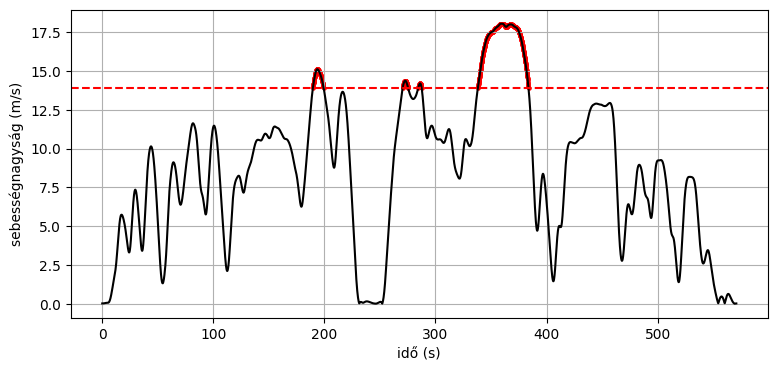

In [27]:
#Hány alakalommal lépte túl az 50km/h sebhatárt mennyi ezen szakaszok össz ideje?
# 50 km/h / 3.6 = m/s


kuszob = 50/3.6

dt = auto.t[1:] - auto.t[:-1]
gyors = auto.v_abs[:-1] > kuszob
gyors_ido = dt[gyors].sum()
uj_szakasz = gyors & np.r_[True, ~gyors[:-1]]
szakaszok_szama = uj_szakasz.sum()

print(f'Küszöb: {kuszob:.2f} m/s')
print(f'Küszöb feletti összidő: {gyors_ido:.1f} s')
print(f'Nagysebességű szakaszok száma: {szakaszok_szama}')

plt.figure(figsize=(9, 4))
plt.plot(auto.t, auto.v_abs, color='black')
plt.scatter(auto.t[:-1][gyors], auto.v_abs[:-1][gyors], color='red', s=5)
plt.axhline(kuszob, color='red', linestyle='--')
plt.xlabel('idő (s)')
plt.ylabel('sebességnagyság (m/s)')
plt.grid()
plt.show()


In [33]:
sebesseg_hatar = 50/3.6
dt = auto.t[1:] - auto.t[:-1]
ds = auto.pathlength[1:] - auto.pathlength[:-1]
v_eredeti = auto.v_abs[:-1]

v_korrigalt = np.minimum(v_eredeti, sebesseg_hatar)
dt_korrigalt = ds / v_korrigalt

print(f'Eredeti menetidő: {dt.sum():.1f} s')
print(f'Hipotetikus menetidő: {dt_korrigalt.sum():.1f} s')
print(f'{dt_korrigalt.sum() - dt.sum():.1f} s')

Eredeti menetidő: 570.9 s
Hipotetikus menetidő: 582.4 s
11.5 s


In [46]:
# mikor fékezett a legerősebben? max tangenciális gyorsulás negatiívan
mikor = auto.a_t_abs.argmin()

print(f'ekkor: {auto.t[mikor]} s-nél szamszeruen: {auto.a_t_abs.min():.2f}')

ekkor: 463.0 s-nél szamszeruen: -1.74


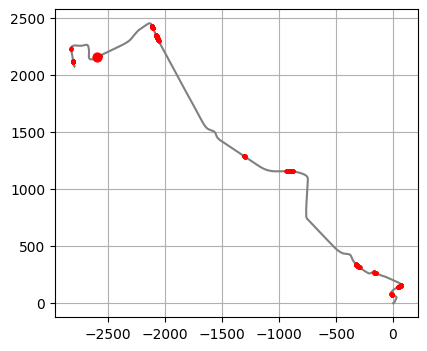

In [82]:
# A legerősebb fékezés indexe.
# Ez egész szám lesz, ezzel lehet indexelni az auto.r és auto.t tömböket.
eros_fekezes_index = auto.a_t_abs.argmin()

# A legerősebb fékezési gyorsulás értéke.
# Ez fizikai érték, m/s²-ben.
legerosebb_fekezes = auto.a_t_abs.min()

# Az erős fékezés küszöbe.
# Példa: ha a legerősebb fékezés -8 m/s², akkor ez -4 m/s².
eros_fekezes_kuszob = legerosebb_fekezes / 2

# Bool maszk: True ott, ahol az autó erősen fékez.
# Mivel fékezésnél a_t negatív, ezért a kisebb érték jelent erősebb fékezést.
eros_fekezes = auto.a_t_abs < eros_fekezes_kuszob

fig = plt.figure(figsize=(14, 4))
ax1 = plt.subplot(111)

# Teljes pályagörbe kirajzolása szürkével.
ax1.plot(auto.r[:, 0], auto.r[:, 1], color="grey")

# A legerősebb fékezés egyetlen pontja.
# Itt indexet használunk, nem küszöbértéket.
ax1.scatter(auto.r[eros_fekezes_index, 0], auto.r[eros_fekezes_index, 1],
            color='red', s=40, zorder=3)

# Az összes erős fékezési pont.
# Itt bool maszkot használunk.
ax1.scatter(auto.r[eros_fekezes, 0], auto.r[eros_fekezes, 1],
            color='red', s=4, zorder=3)

ax1.set_aspect(aspect='equal')
ax1.grid()

plt.show()

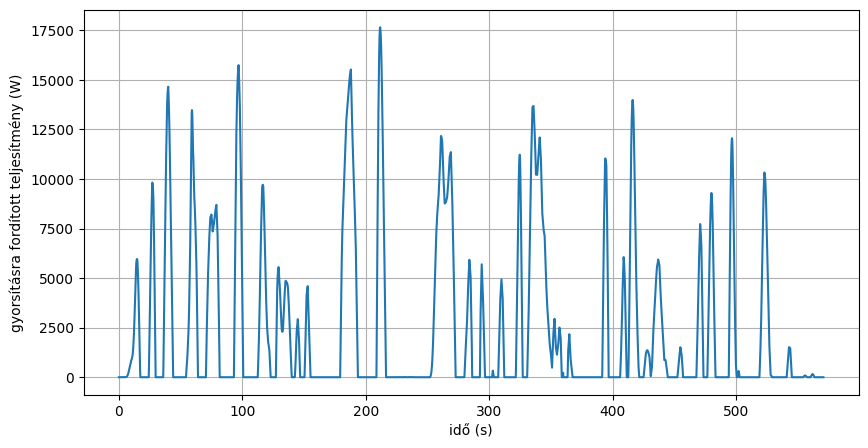

In [77]:
m = 1500  # kg

# P = m * a_t * v képlettel kiszámoljuk a pillanatnyi gyorsítási teljesítményt minden időpontra.
teljesitmeny = m * auto.a_t_abs * auto.v_abs

# Csak a pozitív tangenciális gyorsulás számít gyorsításnak; fékezésnél vagy nulla gyorsulásnál P = 0.
teljesitmeny[auto.a_t_abs <= 0] = 0

fig = plt.figure(figsize=(10, 5))
ax1 = plt.subplot(111)

ax1.plot(auto.t, teljesitmeny)
ax1.set_xlabel('idő (s)')
ax1.set_ylabel('gyorsításra fordított teljesítmény (W)')
ax1.grid()

plt.show()